# Segmentation Olist — 02 Modélisation

**Objectif :** Construire et comparer plusieurs modèles de clustering
pour segmenter les clients Olist.

- **Input :** `data/raw/*.csv`
- **Output :** `data/processed/rfm_features.csv` + modèle MLflow

**Algorithmes testés :**
- K-Means (référence)
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- CAH (Clustering Agglomératif Hiérarchique)

**Métriques d'évaluation :**
- Silhouette Score (plus proche de 1 = meilleur)
- Davies-Bouldin Index (plus proche de 0 = meilleur)

### Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import mlflow
import mlflow.sklearn

# Fixer le répertoire de travail à la racine du projet
PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)
print(f"Répertoire : {os.getcwd()}")

# Imports src/
from src.data.load_data import load_olist
from src.features.build_features import build_features

pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
print("OK Imports")

Répertoire : c:\Users\stg_ly84525\Desktop\olist-customer-segmentation
OK Imports


### Chargement + feature ingineering

In [2]:
# Chargement des données
dfs = load_olist("data/raw")

# Construction des features
df_features = build_features(dfs)
print("\nAperçu des features :")
df_features.head()

OK orders                      99441 lignes x  8 colonnes
OK order_items                112650 lignes x  7 colonnes
OK order_payments             103886 lignes x  5 colonnes
OK order_reviews               99224 lignes x  7 colonnes
OK customers                   99441 lignes x  5 colonnes
Building features...
  Commandes livrées    : 96478
  Calcul recency...
  Calcul frequency...
  Calcul monetary...
  Calcul satisfaction...
  Calcul delivery delay...
  Shape avant imputation : (93358, 6)
  Shape après imputation : (93358, 6)
  Log1p appliqué sur frequency et monetary

Features finales : ['customer_unique_id', 'recency', 'frequency', 'monetary', 'review_score_mean', 'delivery_delay_mean', 'frequency_log', 'monetary_log']
Nb clients       : 93358

Aperçu des features :


,customer_unique_id,recency,frequency,monetary,review_score_mean,delivery_delay_mean,frequency_log,monetary_log
0,0000366f3b9a7992bf8c76cfdf3221e2,113,1,141.90,5.00,-5.00,0.69,4.96
1,0000b849f77a49e4a4ce2b2a4ca5be3f,116,1,27.19,4.00,-5.00,0.69,3.34
2,0000f46a3911fa3c0805444483337064,539,1,86.22,3.00,-2.00,0.69,4.47
3,0000f6ccb0745a6a4b88665a16c9f078,323,1,43.62,4.00,-12.00,0.69,3.80
4,0004aac84e0df4da2b147fca70cf8255,290,1,196.89,5.00,-8.00,0.69,5.29


### Vérification des features

In [3]:
print("Shape :", df_features.shape)
print("\nValeurs manquantes :")
print(df_features.isnull().sum())
print("\nStatistiques descriptives :")
df_features.describe().round(2)

Shape : (93358, 8)

Valeurs manquantes :
customer_unique_id     0
recency                0
frequency              0
monetary               0
review_score_mean      0
delivery_delay_mean    0
frequency_log          0
monetary_log           0
dtype: int64

Statistiques descriptives :


,recency,frequency,monetary,review_score_mean,delivery_delay_mean,frequency_log,monetary_log
count,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00
mean,239.48,1.03,165.17,4.16,-11.77,0.71,4.73
std,152.60,0.21,226.29,1.28,8.93,0.08,0.81
min,2.00,1.00,9.59,1.00,-30.00,0.69,2.36
25%,116.00,1.00,63.01,4.00,-17.00,0.69,4.16
50%,220.00,1.00,107.78,5.00,-12.00,0.69,4.69
75%,348.00,1.00,182.51,5.00,-7.00,0.69,5.21
max,715.00,15.00,13664.08,5.00,30.00,2.77,9.52


### Scalling 
K-Means est aveugle aux unités, il voit uniquement des distances numériques brutes. Sans scaling, recency écrase tout.

In [4]:
# Features retenues pour le clustering
FEATURES = [
    "recency",
    "monetary_log",
    "review_score_mean",
    "delivery_delay_mean",
    "frequency_log",
]

# Extraire la matrice de features
X = df_features[FEATURES].copy()

# StandardScaler : ramène chaque feature à mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

print("Après StandardScaler :")
display(X_scaled.describe().round(3))

Après StandardScaler :


,recency,monetary_log,review_score_mean,delivery_delay_mean,frequency_log
count,93358.00,93358.00,93358.00,93358.00,93358.00
mean,-0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.56,-2.93,-2.47,-2.04,-0.17
25%,-0.81,-0.70,-0.12,-0.59,-0.17
50%,-0.13,-0.05,0.66,-0.03,-0.17
75%,0.71,0.60,0.66,0.53,-0.17
max,3.12,5.93,0.66,4.68,26.95


StandardScaler vs RobustScaler : on aurait pu utiliser RobustScaler (basé sur la médiane et l'IQR — plus robuste aux outliers). On testera les deux dans MLflow. C'est un hyperparamètre à tracker.

### Configuration MLflow

Commande pour runner mlflow en parallèle : mlflow server --host 0.0.0.0 --port 5000 --backend-store-uri mlruns


In [5]:
# MLflow en mode local d'abord — pas besoin du serveur pour logger
# Le serveur sert uniquement à VISUALISER les runs dans le navigateur

import mlflow

# Option A — stockage local (fonctionne sans serveur)
mlflow.set_tracking_uri("mlruns")   # stocke dans ./mlruns/
mlflow.set_experiment("olist-segmentation")

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"OK MLflow configuré")

Tracking URI : mlruns
OK MLflow configuré


In [6]:
mlflow.set_tracking_uri("http://localhost:5000")  # serveur MLflow local
mlflow.set_experiment("olist-segmentation")        # nom de l'expérience

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Expérience   : olist-segmentation")

Tracking URI : http://localhost:5000
Expérience   : olist-segmentation


In [7]:
# Test de connexion MLflow
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("olist-segmentation")
print(f"Expérience créée : {exp}")

Expérience créée : <Experiment: artifact_location='file:c:/Users/stg_ly84525/Desktop/olist-customer-segmentation/mlruns/975050599818781112', creation_time=1774802679112, experiment_id='975050599818781112', last_update_time=1774802679112, lifecycle_stage='active', name='olist-segmentation', tags={}, workspace='default'>


### Méthode Elbow + Silhouette pour choisir K
L'Elbow donne une indication visuelle du bon K, mais reste subjectif. Le Silhouette Score le quantifie objectivement. Les deux ensemble donnent une décision solide.

In [8]:
# Tester K de 2 à 10
K_RANGE = range(2, 11)
inertias = []
silhouettes = []

for k in K_RANGE:
    with mlflow.start_run(run_name=f"kmeans_k{k}"):

        # Entraînement
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)

        # Métriques
        inertia  = kmeans.inertia_
        silhouette = silhouette_score(X_scaled, labels)
        db_score   = davies_bouldin_score(X_scaled, labels)

        inertias.append(inertia)
        silhouettes.append(silhouette)

        # ── MLflow logging ──────────────────────────────────────
        mlflow.log_param("algorithm",   "kmeans")
        mlflow.log_param("n_clusters",  k)
        mlflow.log_param("random_state", 42)
        mlflow.log_param("features",    str(FEATURES))
        mlflow.log_param("scaler",      "StandardScaler")

        mlflow.log_metric("inertia",         inertia)
        mlflow.log_metric("silhouette_score", silhouette)
        mlflow.log_metric("davies_bouldin",   db_score)
        mlflow.log_metric("n_clients",        len(df_features))

        # Sauvegarder le modèle
        mlflow.sklearn.log_model(kmeans, "model")
        # ────────────────────────────────────────────────────────

        print(f"K={k:2d} | inertia={inertia:10.0f} | "
              f"silhouette={silhouette:.4f} | "
              f"davies_bouldin={db_score:.4f}")

print("\n 9 runs MLflow loggés")

2026/03/29 17:34:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 17:34:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


K= 2 | inertia=    376895 | silhouette=0.5909 | davies_bouldin=0.6453
🏃 View run kmeans_k2 at: http://localhost:5000/#/experiments/975050599818781112/runs/611d1f4a2cd143af867d76461ca3b7ea
🧪 View experiment at: http://localhost:5000/#/experiments/975050599818781112


2026/03/29 17:38:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 17:38:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


K= 3 | inertia=    295341 | silhouette=0.3471 | davies_bouldin=1.1488
🏃 View run kmeans_k3 at: http://localhost:5000/#/experiments/975050599818781112/runs/a3c2ce7a507946628b06995f811f86f5
🧪 View experiment at: http://localhost:5000/#/experiments/975050599818781112


2026/03/29 17:41:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 17:41:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

K= 8 | inertia=    154462 | silhouette=0.2250 | davies_bouldin=1.1901
🏃 View run kmeans_k8 at: http://localhost:5000/#/experiments/975050599818781112/runs/9eca605ce5184edb81a1c51e999442fa
🧪 View experiment at: http://localhost:5000/#/experiments/975050599818781112


2026/03/29 17:56:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 17:56:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


K= 9 | inertia=    145175 | silhouette=0.2214 | davies_bouldin=1.2218
🏃 View run kmeans_k9 at: http://localhost:5000/#/experiments/975050599818781112/runs/cf3dd33b4c0145839fcb6d3b8d6fa220
🧪 View experiment at: http://localhost:5000/#/experiments/975050599818781112


2026/03/29 17:59:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 17:59:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


K=10 | inertia=    138046 | silhouette=0.2189 | davies_bouldin=1.1831
🏃 View run kmeans_k10 at: http://localhost:5000/#/experiments/975050599818781112/runs/40d44410772540f596437e5e54da8c94
🧪 View experiment at: http://localhost:5000/#/experiments/975050599818781112

 9 runs MLflow loggés


### Visualisation Elbow + Silhouette

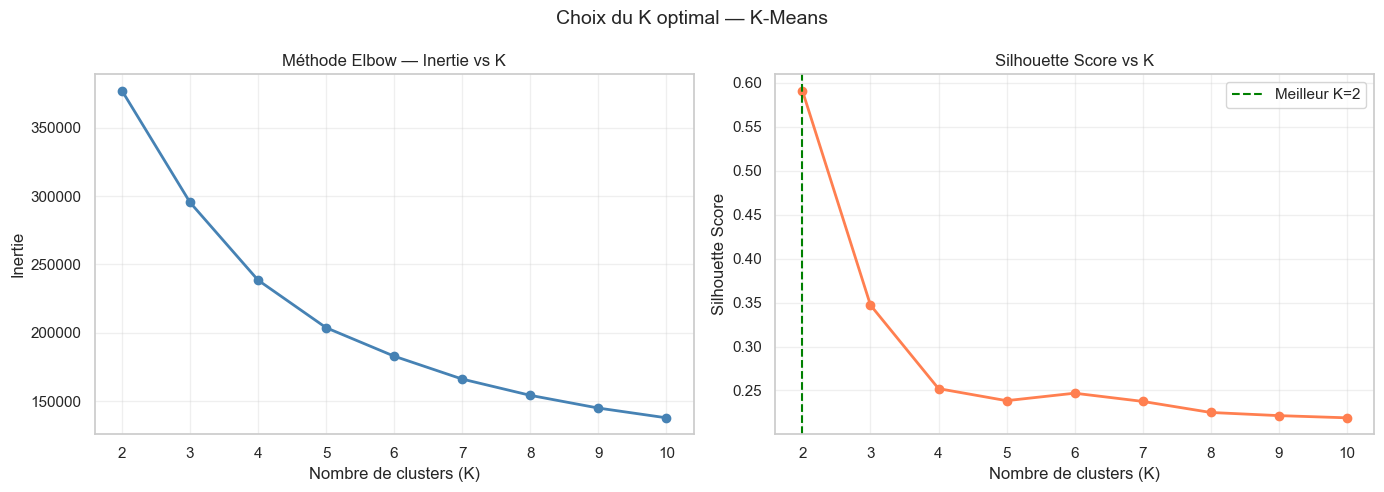

Meilleur K selon Silhouette : 2
Silhouette max              : 0.5909


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, marker="o",
             color="steelblue", linewidth=2)
axes[0].set_title("Méthode Elbow — Inertie vs K")
axes[0].set_xlabel("Nombre de clusters (K)")
axes[0].set_ylabel("Inertie")
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(K_RANGE), silhouettes, marker="o",
             color="coral", linewidth=2)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Nombre de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

# Marquer le meilleur K
best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k, color="green", linestyle="--",
                label=f"Meilleur K={best_k}")
axes[1].legend()

plt.suptitle("Choix du K optimal — K-Means", fontsize=14)
plt.tight_layout()
plt.savefig("models/elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Meilleur K selon Silhouette : {best_k}")
print(f"Silhouette max              : {max(silhouettes):.4f}")

### K-Means final K=4 avec MLflow


K=2 est mathématiquement optimal mais business inutile.

Ce que K=2 donnerait :
- Segment A : "bons clients"
- Segment B : "mauvais clients"

→ 2 campagnes marketing possibles
→ Trop grossier pour être actionnable
L'équipe marketing ne peut pas faire grand chose avec seulement 2 segments. Tout le monde dans "bons clients" reçoit le même email — qu'il soit un acheteur récent à 500 BRL ou un acheteur ancien à 50 BRL.

Ce que K=4 apporte :
Segment 0 : clients récents satisfaits    → campagne fidélisation
Segment 1 : clients anciens à réactiver  → campagne réactivation
Segment 2 : gros acheteurs VIP           → programme premium
Segment 3 : clients insatisfaits         → campagne récupération
4 segments = 4 stratégies distinctes = réelle valeur business.

La règle générale en clustering business :
Score mathématique seul    →  K=2  (toujours trop simple)
Actionabilité seule        →  K=10 (trop fragmenté, ingérable)
Bon compromis              →  K=4 à K=6

Le bon K c'est le plus petit nombre de segments qui permet des actions marketing distinctes et cohérentes.


Pourquoi pas K=3 ou K=5 ?
- K=2  silhouette=0.59  → optimal math   mais trop grossier
- K=3  silhouette=0.35  → chute brutale  → structure forcée
- K=4  silhouette=0.25  → stable         → 4 groupes cohérents
- K=5  silhouette=0.24  → quasi identique à K=4, complexité inutile
- K=3 a un silhouette qui chute brutalement — signe que la 3ème séparation est artificielle. K=4 est le premier K "stable" après K=2 sur le graphique Elbow.

Le silhouette score maximal est obtenu à K=2, mais deux segments ne permettent pas à l'équipe marketing de personnaliser ses campagnes de façon significative. On a retenu K=4 car c'est le premier K stable sur la courbe Elbow, avec un silhouette score acceptable de 0.25, et il produit 4 profils clients distincts et actionnables.

In [11]:
# K retenu : 4 (compromis score / actionabilité business)
BEST_K = 4

with mlflow.start_run(run_name="kmeans_final_k4"):

    # Entraînement
    kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
    df_features["cluster"] = kmeans_final.fit_predict(X_scaled)

    # Métriques
    sil   = silhouette_score(X_scaled, df_features["cluster"])
    db    = davies_bouldin_score(X_scaled, df_features["cluster"])

    # MLflow logging
    mlflow.log_param("algorithm",    "kmeans_final")
    mlflow.log_param("n_clusters",   BEST_K)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("features",     str(FEATURES))
    mlflow.log_param("scaler",       "StandardScaler")
    mlflow.log_param("justification","compromis score/actionabilite")

    mlflow.log_metric("silhouette_score",  sil)
    mlflow.log_metric("davies_bouldin",    db)
    mlflow.log_metric("n_clusters_final",  BEST_K)

    # Sauvegarder modèle + scaler
    mlflow.sklearn.log_model(kmeans_final, "kmeans_model")
    mlflow.sklearn.log_model(scaler,       "scaler")

    # Sauvegarder les features avec clusters
    df_features.to_csv("data/processed/rfm_features.csv", index=False)
    mlflow.log_artifact("data/processed/rfm_features.csv")

    print(f"K={BEST_K} | silhouette={sil:.4f} | davies_bouldin={db:.4f}")
    print(f"Run MLflow : kmeans_final_k4")

# Taille de chaque cluster
print("\nDistribution des clusters :")
print(df_features["cluster"].value_counts().sort_index())

2026/03/29 18:12:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 18:12:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/29 18:13:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 18:13:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

K=4 | silhouette=0.2521 | davies_bouldin=1.2179
Run MLflow : kmeans_final_k4
🏃 View run kmeans_final_k4 at: http://localhost:5000/#/experiments/975050599818781112/runs/4fa9d52800334736b21a86226bc54434
🧪 View experiment at: http://localhost:5000/#/experiments/975050599818781112

Distribution des clusters :
cluster
0    45997
1    30556
2    14004
3     2801
Name: count, dtype: int64


### Description des clusters

Profil moyen par cluster :
         recency  frequency  monetary  review_score_mean  delivery_delay_mean
cluster                                                                      
0         134.60       1.00    147.42               4.66               -12.55
1         403.80       1.00    168.43               4.58               -14.22
2         228.98       1.00    187.66               1.60                -3.75
3         221.81       2.11    308.53               4.21               -12.36


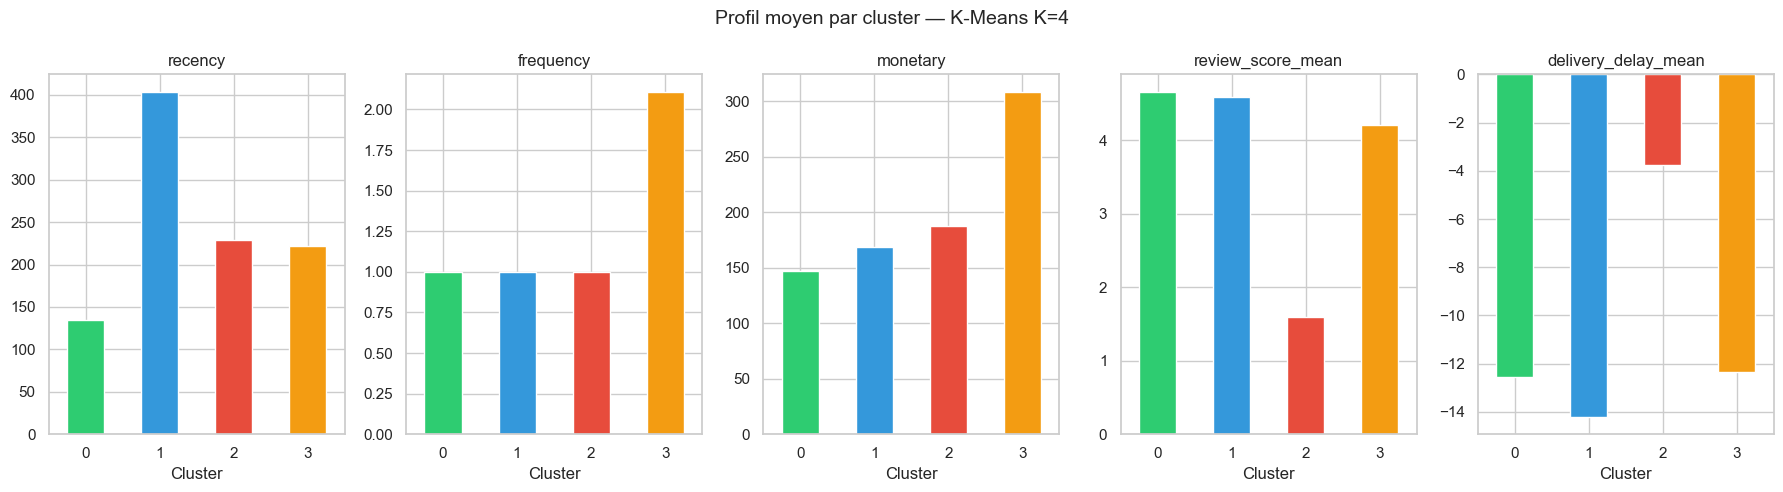

In [12]:
# Profil moyen de chaque cluster (valeurs brutes — lisibles marketing)
profile_cols = [
    "recency", "frequency", "monetary",
    "review_score_mean", "delivery_delay_mean"
]

cluster_profile = (
    df_features
    .groupby("cluster")[profile_cols]
    .mean()
    .round(2)
)

print("Profil moyen par cluster :")
print(cluster_profile)

# Visualisation
fig, axes = plt.subplots(1, len(profile_cols), figsize=(18, 5))
for i, col in enumerate(profile_cols):
    cluster_profile[col].plot(
        kind="bar", ax=axes[i],
        color=["#2ecc71","#3498db","#e74c3c","#f39c12"],
        edgecolor="white"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Profil moyen par cluster — K-Means K=4", fontsize=14)
plt.tight_layout()
plt.savefig("models/cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

### Description business des clusters

In [13]:
# Dictionnaire des noms de segments
SEGMENT_NAMES = {
    0: "Nouveaux satisfaits",
    1: "Clients dormants",
    2: "Clients insatisfaits",
    3: "VIP multi-acheteurs"
}

SEGMENT_STRATEGIES = {
    0: "Fidélisation — offres exclusives pour 2ème achat",
    1: "Réactivation — offre de retour personnalisée",
    2: "Récupération — enquête + geste commercial",
    3: "Programme VIP — service premium"
}

df_features["segment_name"] = df_features["cluster"].map(SEGMENT_NAMES)

# Résumé actionnable pour l'équipe marketing
print("=" * 65)
print("  SEGMENTATION CLIENTS OLIST — LIVRABLE MARKETING")
print("=" * 65)

for cluster_id, name in SEGMENT_NAMES.items():
    subset = df_features[df_features["cluster"] == cluster_id]
    pct = len(subset) / len(df_features) * 100
    print(f"\n{'─'*65}")
    print(f"  Segment {cluster_id} : {name}")
    print(f"  Taille     : {len(subset):>6} clients ({pct:.1f}%)")
    print(f"  Récence    : {subset['recency'].mean():.0f} jours")
    print(f"  Fréquence  : {subset['frequency'].mean():.2f} commandes")
    print(f"  Montant    : {subset['monetary'].mean():.0f} BRL")
    print(f"  Satisfaction: {subset['review_score_mean'].mean():.2f}/5")
    print(f"  Délai      : {subset['delivery_delay_mean'].mean():.1f} jours")
    print(f"  Stratégie  : {SEGMENT_STRATEGIES[cluster_id]}")

print(f"\n{'═'*65}")
print(f"  Total clients segmentés : {len(df_features)}")
print(f"{'═'*65}")

  SEGMENTATION CLIENTS OLIST — LIVRABLE MARKETING

─────────────────────────────────────────────────────────────────
  Segment 0 : Nouveaux satisfaits
  Taille     :  45997 clients (49.3%)
  Récence    : 135 jours
  Fréquence  : 1.00 commandes
  Montant    : 147 BRL
  Satisfaction: 4.66/5
  Délai      : -12.5 jours
  Stratégie  : Fidélisation — offres exclusives pour 2ème achat

─────────────────────────────────────────────────────────────────
  Segment 1 : Clients dormants
  Taille     :  30556 clients (32.7%)
  Récence    : 404 jours
  Fréquence  : 1.00 commandes
  Montant    : 168 BRL
  Satisfaction: 4.58/5
  Délai      : -14.2 jours
  Stratégie  : Réactivation — offre de retour personnalisée

─────────────────────────────────────────────────────────────────
  Segment 2 : Clients insatisfaits
  Taille     :  14004 clients (15.0%)
  Récence    : 229 jours
  Fréquence  : 1.00 commandes
  Montant    : 188 BRL
  Satisfaction: 1.60/5
  Délai      : -3.7 jours
  Stratégie  : Récupération 